# cart-mcp: talking to the MCP server from Python

This notebook is an end-to-end example of **using the cart-mcp MCP server** the way an
MCP client would: we spawn the server as a subprocess, connect over the **MCP protocol**
(stdin/stdout JSON-RPC), and call its tools and resources.

`cart-mcp` computes USDA NRCS CART soil resource concern ratings for an area of
interest (AOI) from published SSURGO data via the public **Soil Data Access** web
service.

What we will do:

1. Spawn `uv run cart-mcp` and negotiate the MCP handshake (`initialize`).
2. Discover the surface (`list_tools`).
3. Explore concerns and rating domains (`list_concerns`, `get_rating_domain`).
4. Rate a real test field from the CART documentation (`rate_aoi`) - this step hits
   the live SDA web service, so it needs internet access.
5. Compare two fields in one pipeline run (`rate_aois`).
6. Read a server resource (`read_resource`).

> **Advisory only:** ratings are an educational estimate of current soil conditions,
> not official NRCS/CART program scores. Official determinations come from your local
> NRCS field office.


```bash
uv sync --extra dev
uv run python -m ipykernel install --user --name cart-mcp --display-name "Python 3 (cart-mcp)"
uv run jupyter lab   # then open examples/cart_mcp_example.ipynb
```


In [1]:
"""Connect to the cart-mcp server over the MCP protocol (stdio transport)."""

import asyncio
import json
import threading
from datetime import timedelta
from pathlib import Path

from mcp.client.session import ClientSession
from mcp.client.stdio import StdioServerParameters, stdio_client

try:
    import cart_mcp
except ImportError:  # fall back to the current working directory
    cart_mcp = None

# Repo root = src/cart_mcp/__init__.py -> parents[2]; uv needs it to find the project.
REPO_ROOT = (
    Path(cart_mcp.__file__).resolve().parents[2]
    if cart_mcp is not None
    else Path.cwd()
)

_loop: asyncio.AbstractEventLoop | None = None
_session: ClientSession | None = None


def _server_thread() -> None:
    """Run the MCP client + server subprocess on a background event loop.

    Jupyter already owns the main thread's event loop, so we keep one dedicated
    loop alive in a daemon thread and drive it from cells with
    `asyncio.run_coroutine_threadsafe` (no nest_asyncio needed).
    """
    global _loop, _session

    _loop = asyncio.new_event_loop()
    asyncio.set_event_loop(_loop)

    params = StdioServerParameters(
        command="uv",
        args=["run", "cart-mcp"],
        cwd=str(REPO_ROOT),
    )

    async def _connect() -> None:
        global _session
        async with stdio_client(params) as (read, write), ClientSession(
            read, write
        ) as session:
            _session = session
            info = await session.initialize()
            print(
                f"connected: server={info.serverInfo.name!r} "
                f"v{info.serverInfo.version} protocol={info.protocolVersion}"
            )
            await asyncio.Future()  # keep the session alive until the kernel exits

    try:
        _loop.run_until_complete(_connect())
    except Exception as exc:  # surface server-side failures in the notebook
        print(f"server thread ended: {exc!r}")


threading.Thread(target=_server_thread, daemon=True).start()


def call(tool: str, *, timeout: float = 180, **kwargs) -> dict:
    """Call an MCP tool and return its parsed JSON payload."""
    if _session is None or _loop is None:
        raise RuntimeError("not connected - wait for the setup cell output")
    future = asyncio.run_coroutine_threadsafe(
        _session.call_tool(
            tool, kwargs or None, read_timeout_seconds=timedelta(seconds=timeout)
        ),
        _loop,
    )
    result = future.result(timeout=timeout + 10)
    if getattr(result, "isError", False):
        text = "".join(b.text for b in result.content if getattr(b, "text", None))
        raise RuntimeError(f"tool {tool!r} failed: {text}")
    payload = "".join(b.text for b in result.content if getattr(b, "text", None))
    return json.loads(payload)


def read(uri: str, *, timeout: float = 30) -> dict:
    """Read an MCP resource and return its parsed JSON payload."""
    future = asyncio.run_coroutine_threadsafe(
        _session.read_resource(uri), _loop
    )
    result = future.result(timeout=timeout)
    text = "".join(b.text for b in result.contents if getattr(b, "text", None))
    return json.loads(text)


def table(rows: list[dict], cols: list[str]) -> str:
    """Render a list of dicts as a simple aligned text table."""
    rows = [
        {c: ("" if row.get(c) is None else str(row[c])) for c in cols} for row in rows
    ]
    widths = {c: max(len(c), *(len(r[c]) for r in rows)) for c in cols}
    header = "  ".join(c.ljust(widths[c]) for c in cols)
    rule = "  ".join("-" * widths[c] for c in cols)
    lines = [header, rule]
    lines += ["  ".join(r[c].ljust(widths[c]) for c in cols) for r in rows]
    return "\n".join(lines)


print("helpers ready")


helpers ready - repo root: REPO_ROOT


connected: server='cart' v2.14.1 protocol=2025-11-25


The cell above starts the server (a subprocess running `uv run cart-mcp`) and
connects a client session. The `call(tool, **kwargs)` and `read(uri)` helpers are
thin sync wrappers over the MCP protocol - exactly what an MCP client does under
the hood.

## 1. Discover the MCP surface

`list_tools` returns the tools registered by the server. We also note the first
line of each tool's description.

In [2]:

import asyncio

future = asyncio.run_coroutine_threadsafe(_session.list_tools(), _loop)
tools = future.result().tools

rows = [
    {
        "name": t.name,
        "description": (t.description or "").splitlines()[0][:80] if t.description else "",
        "args": ",".join(t.inputSchema.get("properties", {}).keys()),
    }
    for t in tools
]
print(table(rows, ["name", "description", "args"]))
print(f"\n{len(tools)} tools registered")


name                        description                                                                       args                 
--------------------------  --------------------------------------------------------------------------------  ---------------------
rate_aoi                    Rate an area of interest (WKT, EPSG:4326) for CART soil resource concerns.        wkt,landunit,concerns
rate_aois                   Rate multiple landunits in one pipeline run.                                      aois,concerns        
get_aoi_soil_summary        Map units and major components intersecting an AOI (no ratings).                  wkt,landunit         
get_aoi_soil_map            Soil map for an AOI as GeoJSON (FeatureCollection).                               wkt,landunit         
get_aoi_risk_map            Risk map for one cointerp-backed concern as GeoJSON (FeatureCollection).          wkt,concern,landunit 
list_concerns               All CART resource concerns with pipeline type, d

## 2. Explore the concern catalog

`list_concerns` is the index of all CART resource concerns. `computable` tells us
whether this server can rate a concern from SSURGO data (true for most; a few need
practice/management inputs this server does not take).

In [3]:

index = call("list_concerns")
rows = [
    {
        "key": c["key"],
        "type": c["type"],
        "computable": "yes" if c["computable"] else "no",
        "source": c["source"][:40],
    }
    for c in index["concerns"]
]
print(table(rows, ["key", "type", "computable", "source"]))


key                                     type  computable  source                                  
--------------------------------------  ----  ----------  ----------------------------------------
Agricultural Organic Soil Subsidence    A     yes         cointerp (mrulename 'SOH - Agricultural 
Soil Susceptibility to Compaction       A     yes         cointerp (mrulename 'SOH - Soil Suscepti
Organic Matter Depletion                A     yes         cointerp (mrulename 'SOH - Organic Matte
Surface Salt Concentration              A     yes         cointerp (mrulename 'SOH - Concentration
Suitability for Aerobic Soil Organisms  A     yes         cointerp (mrulename 'SOH - Suitability f
Aggregate Stability                     A     yes         chorizon (custom formula: 49.7 + 13.7*lo
Ponding Frequency Class                 A     yes         cointerp (mrulename 'Ponding Frequency C
Flooding Frequency Class                A     no          cointerp (mrulename 'Flooding Frequency 
Hydric Rat

## 3. Rating domain for one concern

Each concern rates land into an ordered set of classes. `get_rating_domain`
returns them worst-first for, say, **Soil Organic Carbon Stock** (the only
concern with a custom Type B pipeline - an area-weighted average of SOC stock).

In [4]:

domain = call("get_rating_domain", concern="Soil Organic Carbon Stock")
raw = domain["rating_domain"] or []
classes = raw if isinstance(raw, list) else raw.get("classes", [])
rows = [{"rating_class": c, "rating_value": i} for i, c in enumerate(classes, start=1)]
print(f"concern: {domain['concern']}  (ordered worst -> best)")
print(table(rows, ["rating_value", "rating_class"]))
if isinstance(raw, dict) and raw.get("thresholds_mg_ha"):
    print("\nSOC thresholds (mg/ha, area-weighted mean over the AOI):")
    print(table(raw["thresholds_mg_ha"], ["class", "value", "range"]))


concern: Soil Organic Carbon Stock  (ordered worst -> best)
rating_value  rating_class   
------------  ---------------
1             None           
2             Very low       
3             Low            
4             Moderate       
5             Moderately high
6             High           
7             Not rated      

SOC thresholds (mg/ha, area-weighted mean over the AOI):
class            value  range     
---------------  -----  ----------
None             1      0         
Very low         2      >0 to <10 
Low              3      10 to <25 
Moderate         4      25 to <50 
Moderately high  5      50 to <100
High             6      >=100     
Not rated        7      NULL      


## 4. Rate an area of interest (live SDA)

This is the heart of the server: `rate_aoi` submits the CART SQL pipeline to the
public Soil Data Access service and returns a rating per ratable concern.

We use the **T89 Fld1** test field from `CART/SQL-Library/AOI_Geometry_Examples.txt`
(a Pennsylvania field, survey area PA105, with a High/Medium compaction spread).
The WKT is hardcoded here; EPSG:4326 lon/lat - the only accepted CRS.

> Needs internet access; the public SDA service has no SLA, so occasionally a call
> can fail. The cell prints a clear error rather than crashing if that happens.


In [5]:

landunit = "T89 Fld1"
WKT = "MULTIPOLYGON (((-78.154780969999933 41.650096440000027, -78.155127299999947 41.650196509000068, -78.155959584999948 41.650342944000045, -78.156643053999971 41.650405617000047, -78.157041622999941 41.650358295000046, -78.157623488999945 41.65030407200004, -78.157898182999986 41.650299432000054, -78.158088013999986 41.650144005000072, -78.158314337999968 41.649852229000032, -78.159027929999979 41.650270195000076, -78.159599069999956 41.650112759000081, -78.160214924999934 41.649979300000041, -78.160884953999982 41.649823438000055, -78.161001729999953 41.648889304000079, -78.160903401999974 41.648886874000027, -78.160538823999957 41.648854995000079, -78.160114822999958 41.648787324000068, -78.159674584999948 41.648742125000069, -78.159186138999985 41.648752920000049, -78.158943423999972 41.648724041000037, -78.158775362999961 41.648731321000071, -78.158426522999946 41.648688379000077, -78.158354882999959 41.648583669000061, -78.158072500999936 41.648416557000075, -78.157821589999969 41.648227348000034, -78.157618387999946 41.64799356900005, -78.15765287399995 41.647902922000071, -78.157830635999971 41.648021696000058, -78.158078530999944 41.648279456000068, -78.158333461999973 41.648377264000032, -78.158526800999937 41.648141859000077, -78.158816056999967 41.64780588900004, -78.158223345999943 41.647413788000051, -78.157903313999952 41.647062744000038, -78.158040245999985 41.646723007000048, -78.158242467999969 41.645938812000054, -78.158183047999955 41.645903031000046, -78.157650937999961 41.64586698800008, -78.15687361199997 41.645859186000052, -78.156278061999956 41.645878755000069, -78.156265136999934 41.646518944000036, -78.155991463999953 41.64650073100006, -78.155093772999976 41.646455624000055, -78.154485500999954 41.646417679000081, -78.154290504999949 41.646344223000028, -78.153804593999951 41.646297870000069, -78.153542631999983 41.64636000400003, -78.153527533999977 41.646702755000035, -78.154045596999936 41.648442657000032, -78.154248146999976 41.648344738000048, -78.154445160999956 41.648372494000057, -78.154364470999951 41.648473433000049, -78.154258986999935 41.648791069000026, -78.154455636999955 41.649173380000036, -78.154734490999942 41.649420476000046, -78.15472140899999 41.649717535000036, -78.154780969999933 41.650096440000027), (-78.15543132199997 41.646972377000054, -78.15557394199999 41.647000675000072, -78.15566464799997 41.647029453000073, -78.155747833999953 41.647068662000038, -78.155761680999944 41.647129156000062, -78.155762493999987 41.647217623000074, -78.155685401999961 41.647254628000042, -78.15561213899997 41.647258119000071, -78.155553408999936 41.647306197000034, -78.155500094999979 41.647338486000081, -78.15546388599995 41.647464960000036, -78.155318744999988 41.647440138000036, -78.15515090599996 41.647395293000045, -78.154899358999955 41.647323607000033, -78.15471331699996 41.647317233000081, -78.154599042999962 41.647287879000032, -78.154502117999982 41.647239476000038, -78.154407943999956 41.647182306000047, -78.154418899999939 41.647094121000066, -78.154429944999947 41.647004183000035, -78.154446546999964 41.646894911000061, -78.154469775999985 41.646849493000047, -78.154579411999975 41.646876976000044, -78.15474110699995 41.64690044300005, -78.154861104999952 41.646906955000077, -78.154990361999978 41.646917227000074, -78.155079043999933 41.646991957000068, -78.155187652999984 41.646989334000068, -78.155312101999982 41.646948206000047, -78.15543132199997 41.646972377000054)))"

print("T89 Fld1: Pennsylvania field (PA105)")
print("wkt:", WKT[:60], "...")

try:
    out = call("rate_aoi", wkt=WKT, landunit=landunit)
except Exception as exc:
    print("rate_aoi failed - is SDA reachable? error:", exc)
else:
    ratings = sorted(out["ratings"], key=lambda r: (r["landunit"], r["rating_name"]))
    rows = [
        {
            "landunit": r["landunit"],
            "rating_name": r["rating_name"],
            "rating_class": r["rating_class"],
            "rating_value": r["rating_value"],
            "soils_metadata": r.get("soils_metadata") or "",
        }
        for r in ratings
    ]
    print(table(rows, ["landunit", "rating_name", "rating_class", "rating_value", "soils_metadata"]))
    print(f"\n{len(ratings)} ratings returned")
    print("\ndisclaimer:", out["disclaimer"][:120], "...")


T89 Fld1: Pennsylvania field (PA105)
wkt: MULTIPOLYGON (((-78.154780969999933 41.650096440000027, -78. ...
landunit  rating_name                             rating_class                   rating_value  soils_metadata           
--------  --------------------------------------  -----------------------------  ------------  -------------------------
T89 Fld1  Aggregate Stability                     Moderate                       2             PA105 2025-09-04 13:13:25
T89 Fld1  Agricultural Organic Soil Subsidence    Mineral soil                   4             PA105 2025-09-04 13:13:25
T89 Fld1  Available Water Storage                 Yes                            1             PA105 2025-09-04 13:13:25
T89 Fld1  Easements Drainage                      No                             0             PA105 2025-09-04 13:13:25
T89 Fld1  Easements Farm Class                    No                             0             PA105 2025-09-04 13:13:25
T89 Fld1  Easements Hydric Soils              

## 5. MCP resources

Servers can also expose named **resources**. `cart://domains/{concern}` returns
the same rating domain data as the tool, as a browsable resource.

In [6]:

resource = read("cart://domains/Soil Organic Carbon Stock")
print("uri: cart://domains/Soil Organic Carbon Stock")
print(json.dumps(resource["rating_domain"], indent=2))


uri: cart://domains/Soil Organic Carbon Stock
{
  "source": "docs/reference/rating_domains.md",
  "classes": [
    "None",
    "Very low",
    "Low",
    "Moderate",
    "Moderately high",
    "High",
    "Not rated"
  ],
  "thresholds_mg_ha": [
    {
      "class": "None",
      "value": 1,
      "range": "0"
    },
    {
      "class": "Very low",
      "value": 2,
      "range": ">0 to <10"
    },
    {
      "class": "Low",
      "value": 3,
      "range": "10 to <25"
    },
    {
      "class": "Moderate",
      "value": 4,
      "range": "25 to <50"
    },
    {
      "class": "Moderately high",
      "value": 5,
      "range": "50 to <100"
    },
    {
      "class": "High",
      "value": 6,
      "range": ">=100"
    },
    {
      "class": "Not rated",
      "value": 7,
      "range": "NULL"
    }
  ]
}


## 6. Soil map and risk map (GeoJSON)

The server returns maps as **GeoJSON `FeatureCollection`s**, not images:

- `get_aoi_soil_map` - every soil polygon clipped to the AOI, with map unit
  properties (`musym`, `muname`, `invesintens`, `poly_acres`, ...)
- `get_aoi_risk_map` - the same polygons, each carrying the rating
  (`rating_value`/`rating_class`) of the dominant major soil component in its map
  unit. Cointerp-backed concerns only; Order 5 survey units are `Not rated`.

We fetch both maps for T89 Fld1, rated for Soil Susceptibility to Compaction
(a High/Medium severity spread).

In [7]:

CONCERN = "Soil Susceptibility to Compaction"
soil = call("get_aoi_soil_map", wkt=WKT, landunit=landunit)
risk = call("get_aoi_risk_map", wkt=WKT, concern=CONCERN, landunit=landunit)
classes = sorted({f["properties"]["rating_class"] for f in risk["features"]})
print(f"{landunit}: {soil['feature_count']} soil polygons, compaction classes: {classes}")


T89 Fld1: 15 soil polygons, compaction classes: ['High', 'Medium']


## 7. Convert to GeoDataFrames

`gpd.GeoDataFrame.from_features` turns each FeatureCollection into a GeoDataFrame:
geometry is read from the GeoJSON and the feature properties become the columns
(`musym`, `muname`, `poly_acres`, `mukey`, ... - including `landunit`, already in
the properties). The CRS is EPSG:4326, matching the AOI WKT convention.

In [8]:

import geopandas as gpd

soil_gdf = gpd.GeoDataFrame.from_features(soil["features"], crs="EPSG:4326")
risk_gdf = gpd.GeoDataFrame.from_features(risk["features"], crs="EPSG:4326")
print(f"soil: {len(soil_gdf)} features | risk: {len(risk_gdf)} features")


soil: 15 features | risk: 15 features


## 8. Plot map

Two panels with a shared extent (same AOI, so they line up):

- **Soil map** - polygons colored by map unit symbol (`musym`, categorical `tab20`),
  **no legend** - instead each polygon is labeled with its `mukey` at its centroid
- **Risk map** - choropleth by `rating_class`, coerced to an ordered Categorical
  (High > Medium > Low > Not rated) and colored by severity
  (red / orange / green / gray) with a legend.

A dotted graticule, axis labels, and an advisory footnote complete the figure.

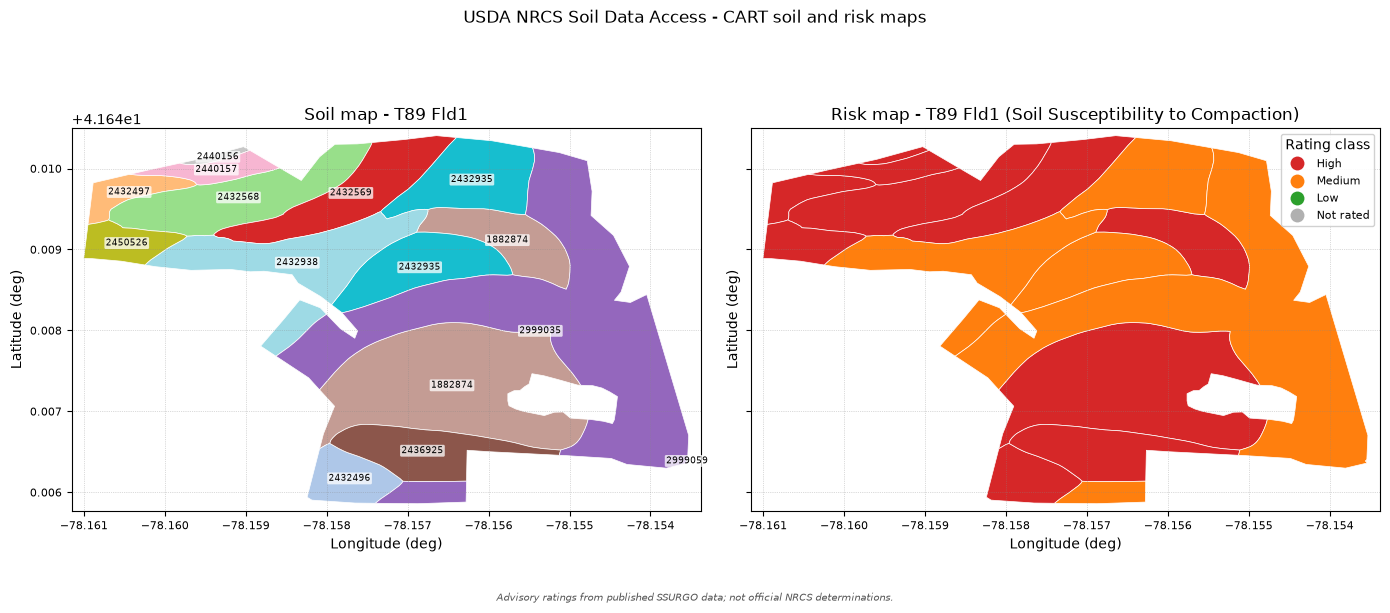

In [9]:

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import pandas as pd

RATING_ORDER = ["High", "Medium", "Low", "Not rated"]
RATING_COLORS = {
    "High": "#d62728",
    "Medium": "#ff7f0e",
    "Low": "#2ca02c",
    "Not rated": "#b0b0b0",
}

risk_gdf["rating_class"] = pd.Categorical(
    risk_gdf["rating_class"], categories=RATING_ORDER, ordered=True
)
risk_cmap = mcolors.ListedColormap([RATING_COLORS[c] for c in RATING_ORDER])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

soil_gdf.plot(
    ax=ax1, column="musym", categorical=True, cmap="tab20",
    edgecolor="white", linewidth=0.5,
)
for mukey, geom in zip(soil_gdf["mukey"], soil_gdf.geometry):
    centroid = geom.centroid
    ax1.annotate(
        str(mukey), xy=(centroid.x, centroid.y), ha="center", va="center",
        fontsize=6.5, color="black",
        bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.75),
    )
ax1.set_title(f"Soil map - {landunit}")

risk_gdf.plot(
    ax=ax2, column="rating_class", categorical=True, cmap=risk_cmap,
    edgecolor="white", linewidth=0.5, legend=True,
    legend_kwds={"title": "Rating class", "loc": "upper right",
                 "framealpha": 0.9, "fontsize": 8},
)
ax2.set_title(f"Risk map - {landunit} ({CONCERN})")

xmin, ymin, xmax, ymax = soil_gdf.total_bounds
pad_x, pad_y = (xmax - xmin) * 0.02, (ymax - ymin) * 0.02
for ax in (ax1, ax2):
    ax.set_aspect("equal")
    ax.set_xlim(xmin - pad_x, xmax + pad_x)
    ax.set_ylim(ymin - pad_y, ymax + pad_y)
    ax.set_xlabel("Longitude (deg)")
    ax.set_ylabel("Latitude (deg)")
    ax.grid(True, linestyle=":", linewidth=0.5, alpha=0.6, color="#888888")
    ax.tick_params(labelsize=8)

fig.suptitle("USDA NRCS Soil Data Access - CART soil and risk maps", fontsize=12, y=0.99)
fig.text(
    0.5, 0.005,
    "Advisory ratings from published SSURGO data; not official NRCS determinations.",
    ha="center", fontsize=7, style="italic", color="#555555",
)
plt.tight_layout()
plt.show()


## Wrap-up

The client session lives in a daemon thread, so it dies with the kernel - nothing
to clean up. What you saw is the full MCP contract:

| Aspect | Example |
|---|---|
| handshake | `initialize` (protocol version negotiated) |
| discovery | `list_tools`, `read_resource` |
| tools | `list_concerns`, `get_rating_domain`, `rate_aoi`, `rate_aois`, `get_aoi_soil_map`, `get_aoi_risk_map`, ... |
| results | JSON payloads, advisory disclaimer, survey dates (`soils_metadata`), GeoJSON map layers |

Next steps:

- Run the full protocol validation: call `validate_pipeline` (re-runs the pipeline
  against the embedded golden values).
- Use the same server from an MCP-capable client - see `examples/mcp_config.json`.
- Serve it over SSE for remote use: `uv run cart-mcp --transport sse --port 8000`.

See the public CART reference repository (https://github.com/jneme910/CART) for details.
